# Protótipo do modelo de classificação

1 - Importações

In [20]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

2 - Importação do modelo pré-treinado

In [21]:
pre_treined_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False)

3 - Criação das camadas densas personalizadas

In [22]:
x = pre_treined_model.output

In [23]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)

In [24]:
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

predis = tf.keras.layers.Dense(7, activation='softmax')(x)

In [25]:
modelo_classificacao = tf.keras.Model(inputs = pre_treined_model.input, outputs = predis)

In [26]:
for i, layer in enumerate(modelo_classificacao.layers):
    print(i, layer)

0 <InputLayer name=input_layer_1, built=True>
1 <ZeroPadding2D name=conv1_pad, built=True>
2 <Conv2D name=conv1_conv, built=True>
3 <BatchNormalization name=conv1_bn, built=True>
4 <Activation name=conv1_relu, built=True>
5 <ZeroPadding2D name=pool1_pad, built=True>
6 <MaxPooling2D name=pool1_pool, built=True>
7 <Conv2D name=conv2_block1_1_conv, built=True>
8 <BatchNormalization name=conv2_block1_1_bn, built=True>
9 <Activation name=conv2_block1_1_relu, built=True>
10 <Conv2D name=conv2_block1_2_conv, built=True>
11 <BatchNormalization name=conv2_block1_2_bn, built=True>
12 <Activation name=conv2_block1_2_relu, built=True>
13 <Conv2D name=conv2_block1_0_conv, built=True>
14 <Conv2D name=conv2_block1_3_conv, built=True>
15 <BatchNormalization name=conv2_block1_0_bn, built=True>
16 <BatchNormalization name=conv2_block1_3_bn, built=True>
17 <Add name=conv2_block1_add, built=True>
18 <Activation name=conv2_block1_out, built=True>
19 <Conv2D name=conv2_block2_1_conv, built=True>
20 <BatchNo

4 - Configurando as camadas que densas para treinar e congelando as demais

In [27]:
for layer in modelo_classificacao.layers[:175]:
    layer.trainable = False

In [28]:
for layer in modelo_classificacao.layers[175:]:
    layer.trainable = True

5 - Preparação e Treinamento do Modelo

In [29]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
                                                                validation_split = 0.2)

In [30]:
train_generator = train_datagen.flow_from_directory('./train_images_classification',
                                                    target_size = (224,224),
                                                    color_mode = 'rgb',
                                                    batch_size = 32,
                                                    class_mode = 'categorical',
                                                    shuffle = True,
                                                    subset = 'training'
                                                    )

Found 604 images belonging to 7 classes.


In [31]:
train_generator.class_indices

{'leprosy borderline': 0,
 'leprosy ideterminate': 1,
 'leprosy lepromatous': 2,
 'leprosy neural': 3,
 'leprosy tuberculoid-nodular (leprosy of childhood)': 4,
 'leprosy tuberculoide': 5,
 'stasis eczema and leprosy tuberculoid': 6}

In [32]:
modelo_classificacao.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
# reduz a taxa de aprendizado automaticamente quando a métrica de 
# desempenho (como a acurácia ou a loss de validação) para de melhorar

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',        # Pode ser 'val_accuracy' também
    factor=0.2,                # Fator de redução da taxa (por ex: 0.2 => 1e-3 vira 2e-4)
    patience=2,                # Espera 3 épocas sem melhora antes de reduzir
    min_lr=1e-6,               # Valor mínimo da learning rate
    verbose=1
)

In [34]:
history = modelo_classificacao.fit(train_generator, 
                     epochs=10) 
# A redução da taxa de aprendizagem não apresentou resultados bons para esse modelo

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.3738 - loss: 1.6608
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6104 - loss: 0.9135
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.7772 - loss: 0.5865
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.8823 - loss: 0.3211
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9331 - loss: 0.2242
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9661 - loss: 0.1304
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9844 - loss: 0.0656
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.9995 - loss: 0.0265
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9997 - loss: 0.0101
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 1.0000 - loss: 0.0070


In [35]:
from utils.models_pkl import save_model

save_model(modelo_classificacao, "modelo_classificacao")

6 - Avaliação do Modelo

Text(0.5, 0, 'Perda em relação ao valor Real')

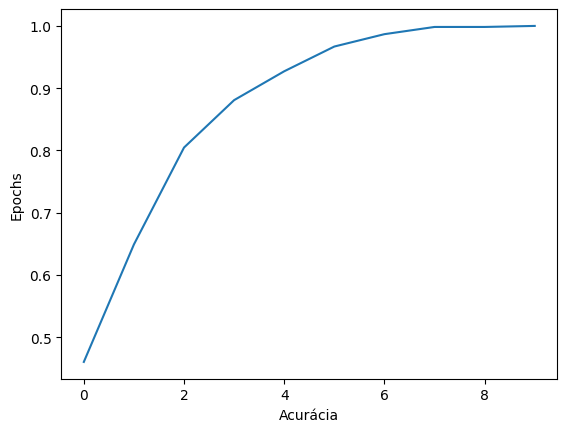

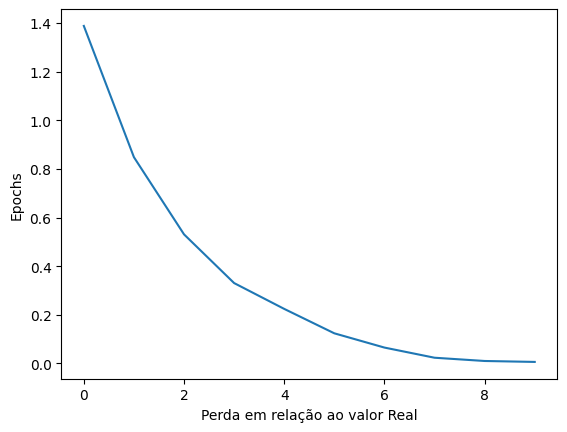

In [36]:
accuracy = history.history["accuracy"]
loss = history.history["loss"]

plt.figure()
plt.plot(accuracy, label="Evolução da Acurácia Durante Treinamento")
plt.ylabel("Epochs")
plt.xlabel("Acurácia")

plt.figure()
plt.plot(loss, label="Evolução da Precisão Durante Treinamento")
plt.ylabel("Epochs")
plt.xlabel("Perda em relação ao valor Real")